In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### 1. Load Dataset & Inspect Structure

In [2]:
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

In [3]:
df = pd.read_csv(r'C:\Users\faraz\Downloads\winequality-red.csv')

In [4]:
print (df.shape)

(1599, 12)


In [5]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [7]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB
None


In [8]:
print(df.isnull().sum())

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64


In [9]:
print(df['quality'].value_counts().sort_index())

quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64


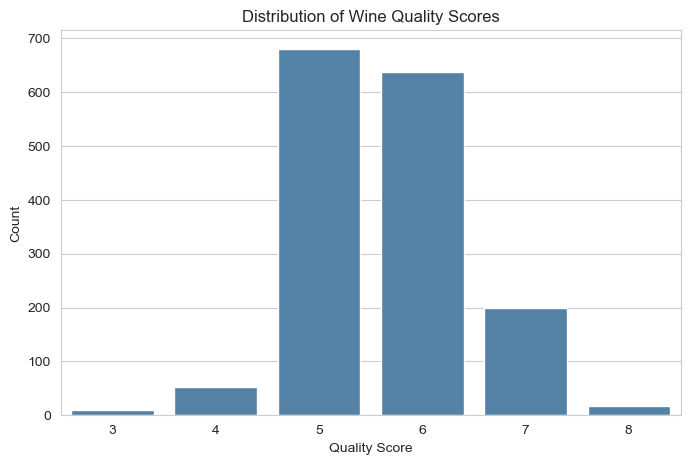

In [10]:
plt.figure(figsize=(8, 5))
sns.countplot(x='quality', data=df, color='steelblue')
plt.title('Distribution of Wine Quality Scores')
plt.xlabel('Quality Score')
plt.ylabel('Count')
plt.show()

-----------------

*The bar chart tells the story of a vineyard's harvest where mediocrity rules the day and true excellence is a rare treasure. If you look at the towering peaks in the center, it becomes clear that the vast majority of the wines produced are thoroughly average, with scores of 5 and 6 dominating the entire collection. These middle-of-the-road bottles make up the bulk of the cellar, while the true outliers tell a story of extremes. On one end of the spectrum, the winemakers managed to avoid disaster most of the time, as seen by the tiny handful of truly terrible wines rated at a 3 or 4. On the other end, perfection proved just as elusive, with only a rare few bottles achieving the highly coveted distinction of an 8. For a data scientist stepping into this vineyard, this chart is a warning that any predictive model will naturally become biased toward calling every bottle "average" simply because it has seen so few examples of failure or perfection. To truly unlock the secrets of what makes a wine exceptional, one would have to artificially balance the scales, giving those rare, top-shelf bottles a louder voice in the data.*

-----------------

### 2. EDA: Distributions & Correlation Heatmap

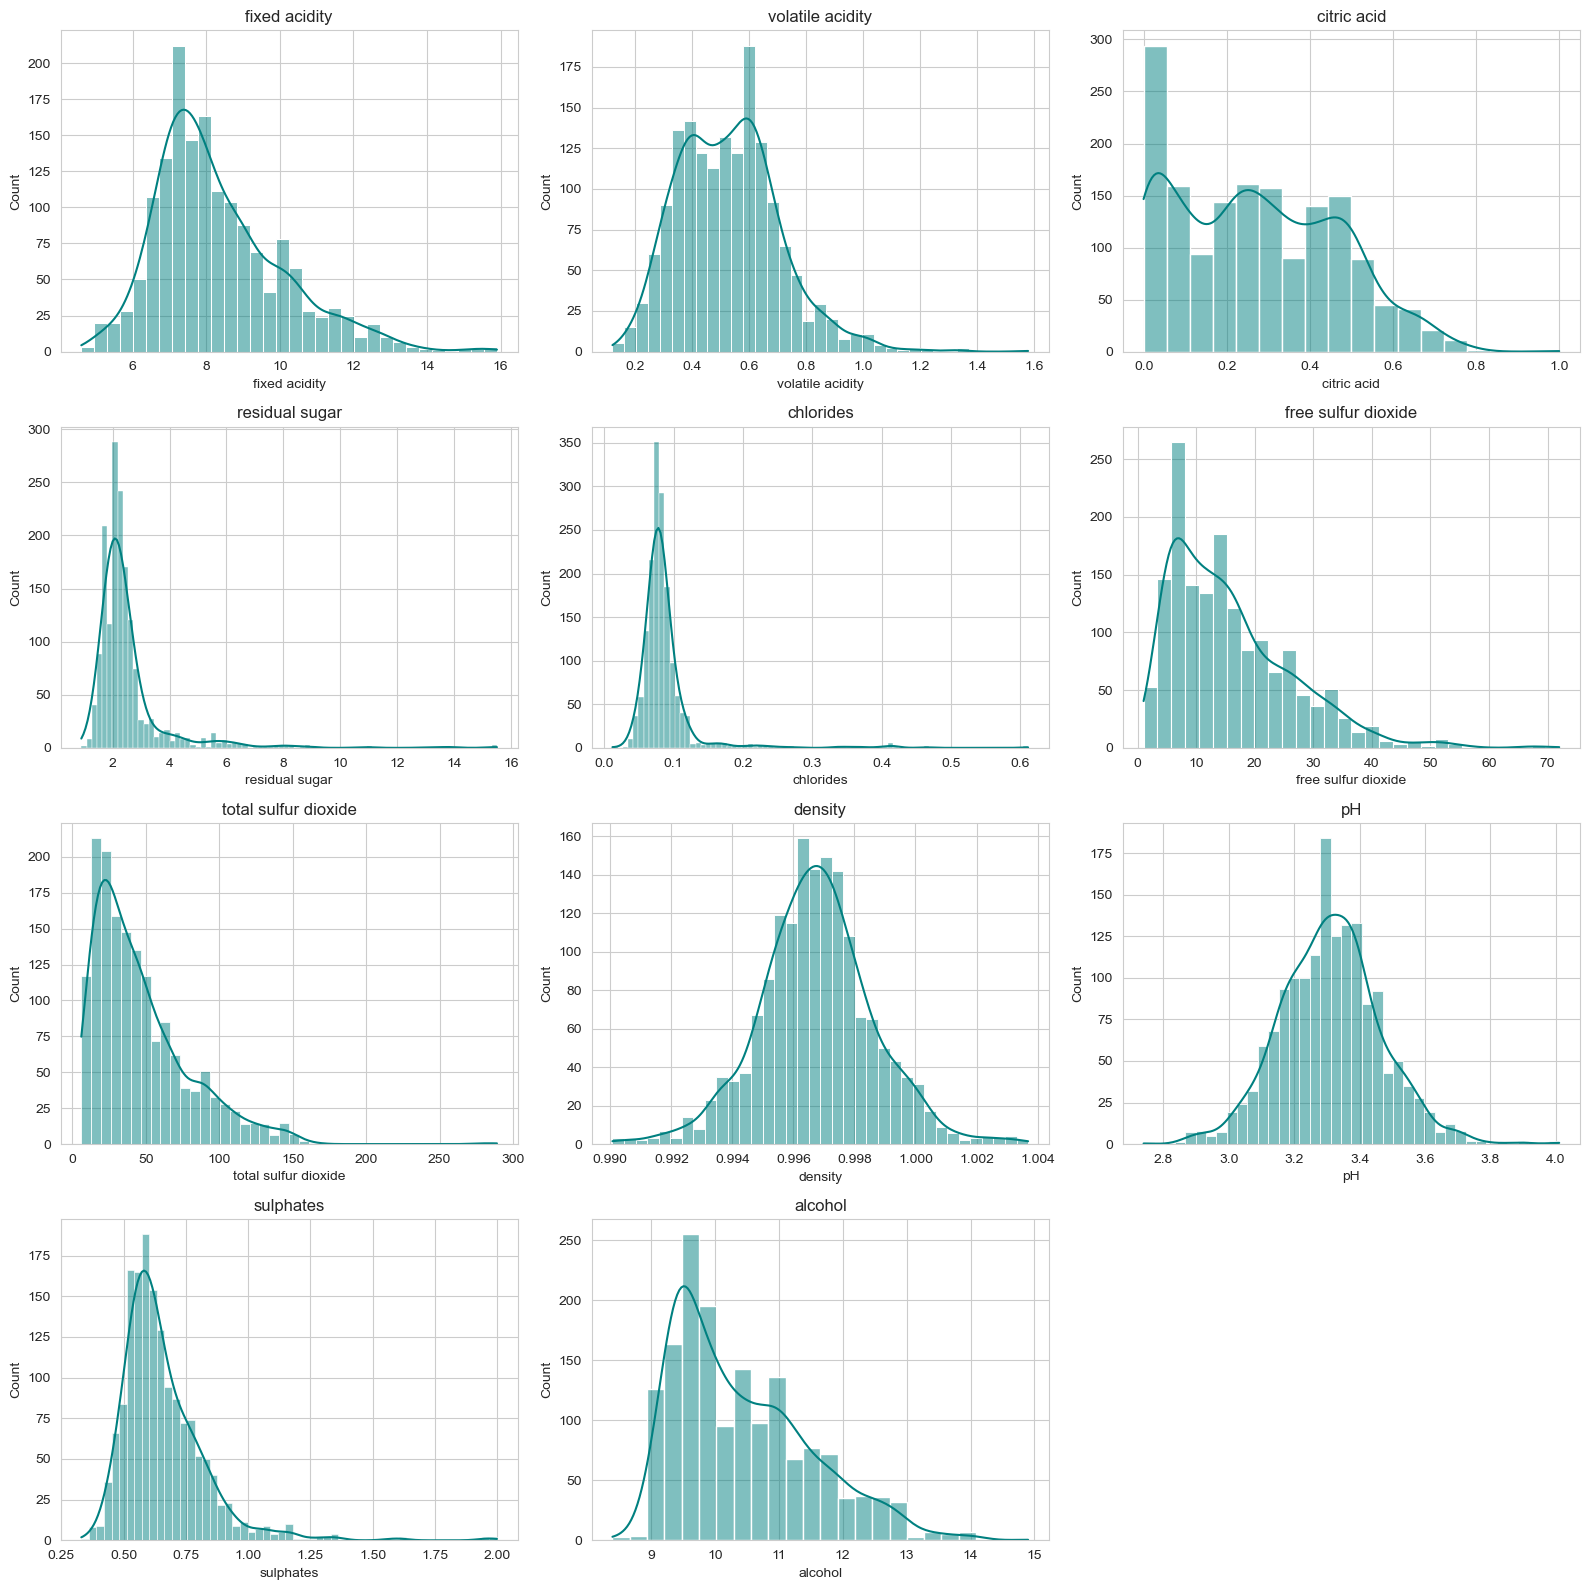

In [13]:
features = df.columns.drop('quality')
fig, axes = plt.subplots(4, 3, figsize=(16, 16))
axes = axes.flatten()

for i, col in enumerate(features):
    sns.histplot(df[col], kde=True, ax=axes[i], color='teal')
    axes[i].set_title(col)
axes[-1].axis('off')
plt.tight_layout()
plt.show()

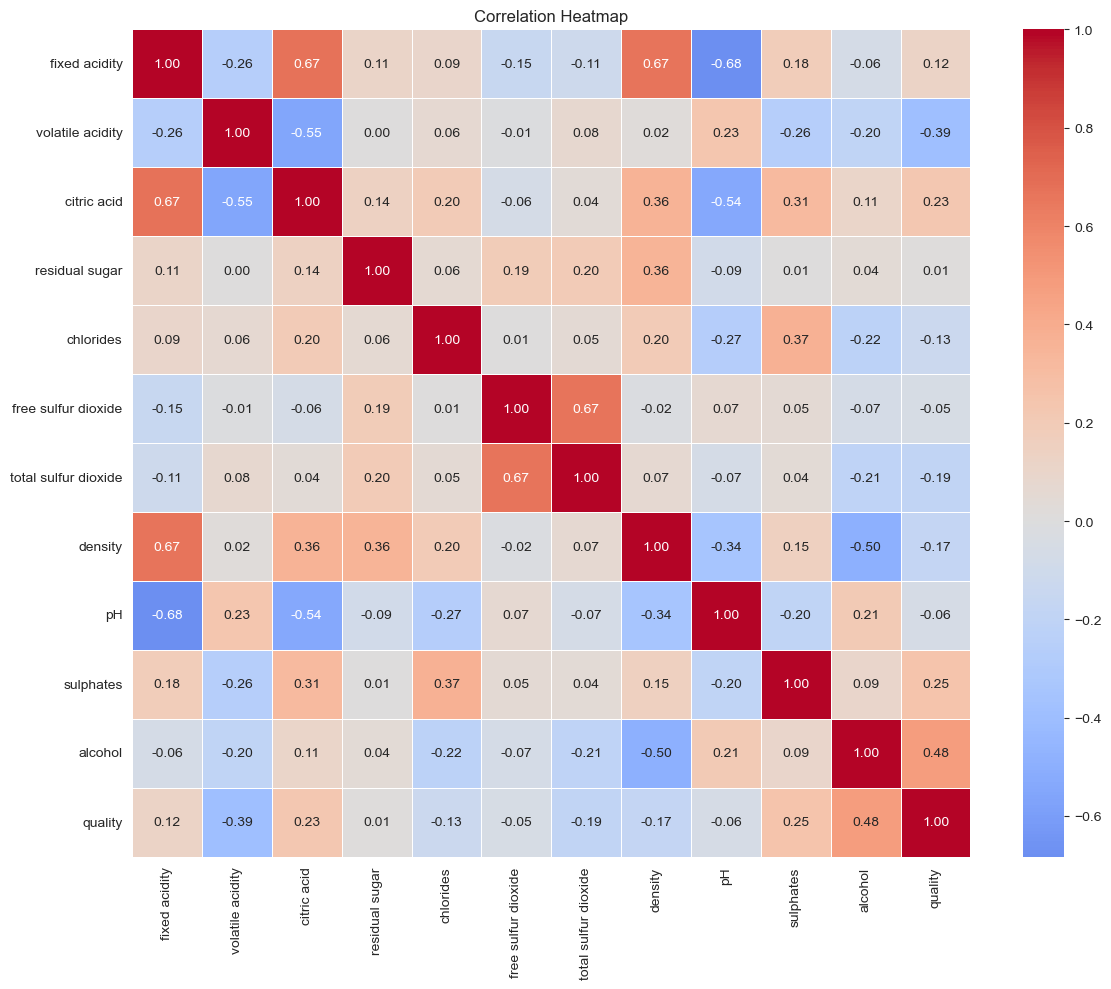

In [14]:
plt.figure(figsize=(12, 10))
corr = df.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

In [15]:
print(corr['quality'].sort_values(ascending=False))

quality                 1.000000
alcohol                 0.476166
sulphates               0.251397
citric acid             0.226373
fixed acidity           0.124052
residual sugar          0.013732
free sulfur dioxide    -0.050656
pH                     -0.057731
chlorides              -0.128907
density                -0.174919
total sulfur dioxide   -0.185100
volatile acidity       -0.390558
Name: quality, dtype: float64


## Class Imbalance Discussion

Quality scores are heavily skewed: scores 5 and 6 dominate (681 and 638 samples out of 1599),
while extreme scores (3, 4, 8) have very few samples (10, 53, 18 respectively). Score 7 has 199.

This imbalance means:
- A classifier predicting only the majority classes (5/6) could score high accuracy while
  completely failing on rare classes.
- Multi-class classification (3–8) will struggle on minority classes due to insufficient
  training examples — precision/recall on classes 3, 4, and 8 will likely be poor or undefined.
- Stratified train/test splitting is essential to preserve class ratios in both sets.
- Binning into fewer, more balanced categories (e.g. good/bad, or low/medium/high) is a
  practical way to make the problem more tractable and the classes more balanced.

In [16]:
print("Class imbalance ratio (max/min):", 
      df['quality'].value_counts().max() / df['quality'].value_counts().min())

Class imbalance ratio (max/min): 68.1


### 4. Feature Engineering: Binning Quality Scores

In [18]:
df['quality_binary'] = (df['quality'] >= 7).astype(int)
print(df['quality_binary'].value_counts())

quality_binary
0    1382
1     217
Name: count, dtype: int64


In [19]:
def bin_quality(q):
    if q <= 4:
        return 'low'
    elif q <= 6:
        return 'medium'
    else:
        return 'high'

df['quality_3class'] = df['quality'].apply(bin_quality)
print(df['quality_3class'].value_counts())

quality_3class
medium    1319
high       217
low         63
Name: count, dtype: int64


## Binning Justification

We proceed with the **binary framing (good ≥7 vs. not good)** as the primary target because:
- It directly mirrors the task tip (AUC/ROC evaluation, cutoff at 7).
- It creates a more usable minority class (good wines: ~217/1599 ≈ 13.6%) vs. the almost
  unusable 10-sample class 3 or 18-sample class 8 in the raw 6-class problem.
- It's business-relevant: many real-world use cases just need "is this wine good enough to
  recommend/sell as premium" rather than an exact 3–8 score.

The 3-class version is kept as an optional extension for a slightly more granular view than
binary, while still avoiding the near-empty extreme classes.

### 5. Train/Test Split with Stratification

In [22]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['quality', 'quality_binary', 'quality_3class'])
y = df['quality_binary']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print("Train class balance:\n", y_train.value_counts(normalize=True))
print("Test class balance:\n", y_test.value_counts(normalize=True))

Train class balance:
 quality_binary
0    0.864053
1    0.135947
Name: proportion, dtype: float64
Test class balance:
 quality_binary
0    0.865
1    0.135
Name: proportion, dtype: float64


### 6. Scale Features (needed for SGD and SVC)

In [24]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### 7. Train 3 Classifiers

In [25]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.svm import SVC

In [32]:
# Random Forest 
rf = RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced')
rf.fit(X_train, y_train)

# SGD Classifier 
sgd = SGDClassifier(loss='log_loss', random_state=42, class_weight='balanced')
sgd.fit(X_train_scaled, y_train)

# Support Vector Classifier 
svc = SVC(probability=True, random_state=42, class_weight='balanced')
svc.fit(X_train_scaled, y_train)

print("All 3 models trained.")

All 3 models trained.


### 8. Evaluate Each Model

In [34]:
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, roc_auc_score, roc_curve)

models = {
    'Random Forest': (rf, X_test),
    'SGD': (sgd, X_test_scaled),
    'SVC': (svc, X_test_scaled)
}

for name, (model, X_te) in models.items():
    y_pred = model.predict(X_te)
    print(f"\n{'='*50}\n{name}\n{'='*50}")
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print(classification_report(y_test, y_pred))


Random Forest
Accuracy: 0.9400
              precision    recall  f1-score   support

           0       0.94      0.99      0.97       346
           1       0.92      0.61      0.73        54

    accuracy                           0.94       400
   macro avg       0.93      0.80      0.85       400
weighted avg       0.94      0.94      0.93       400


SGD
Accuracy: 0.7200
              precision    recall  f1-score   support

           0       0.95      0.71      0.81       346
           1       0.30      0.78      0.43        54

    accuracy                           0.72       400
   macro avg       0.62      0.74      0.62       400
weighted avg       0.86      0.72      0.76       400


SVC
Accuracy: 0.8325
              precision    recall  f1-score   support

           0       0.96      0.84      0.90       346
           1       0.43      0.76      0.55        54

    accuracy                           0.83       400
   macro avg       0.69      0.80      0.72       40

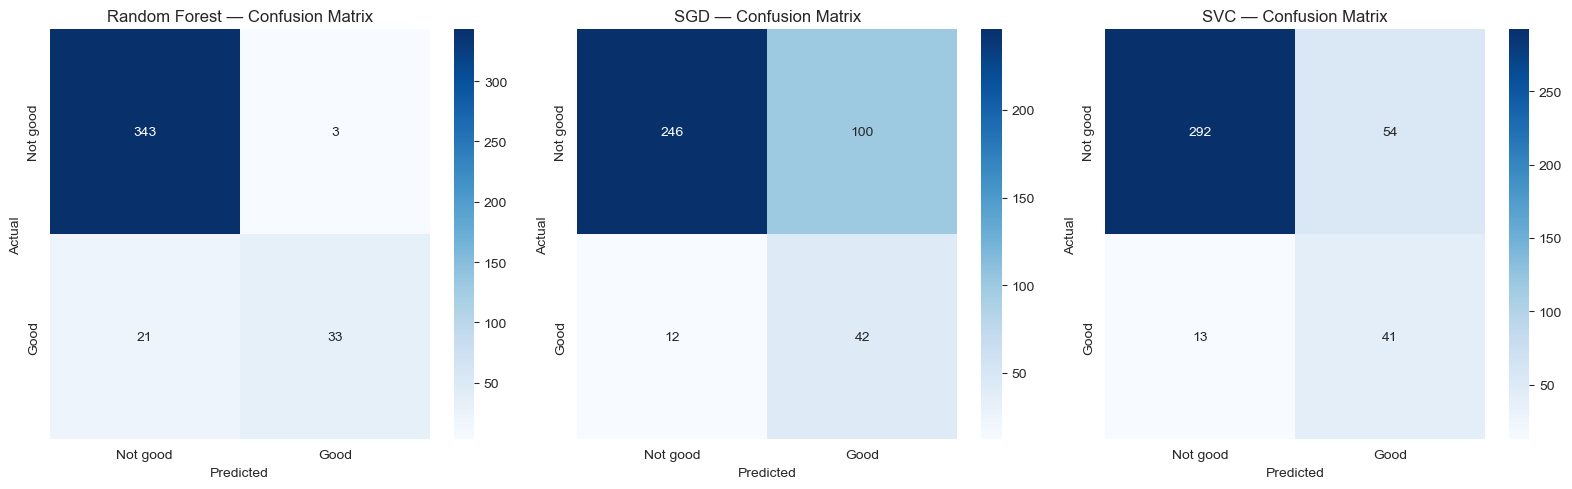

In [35]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (name, (model, X_te)) in zip(axes, models.items()):
    y_pred = model.predict(X_te)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Not good', 'Good'], yticklabels=['Not good', 'Good'])
    ax.set_title(f'{name} — Confusion Matrix')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

### 9. ROC Curves & AUC

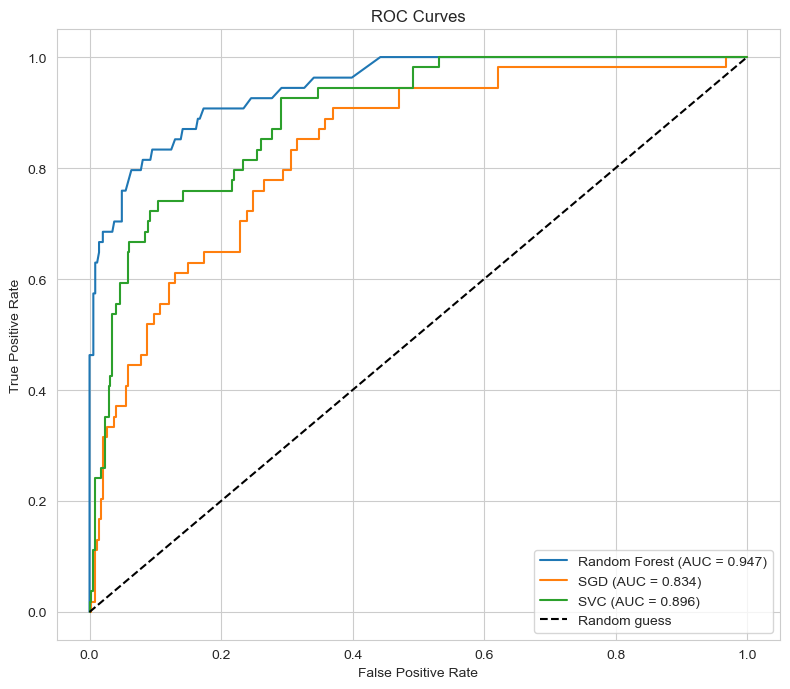

In [36]:
plt.figure(figsize=(8, 7))

for name, (model, X_te) in models.items():
    y_proba = model.predict_proba(X_te)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend()
plt.tight_layout()
plt.show()

### 10. Feature Importance

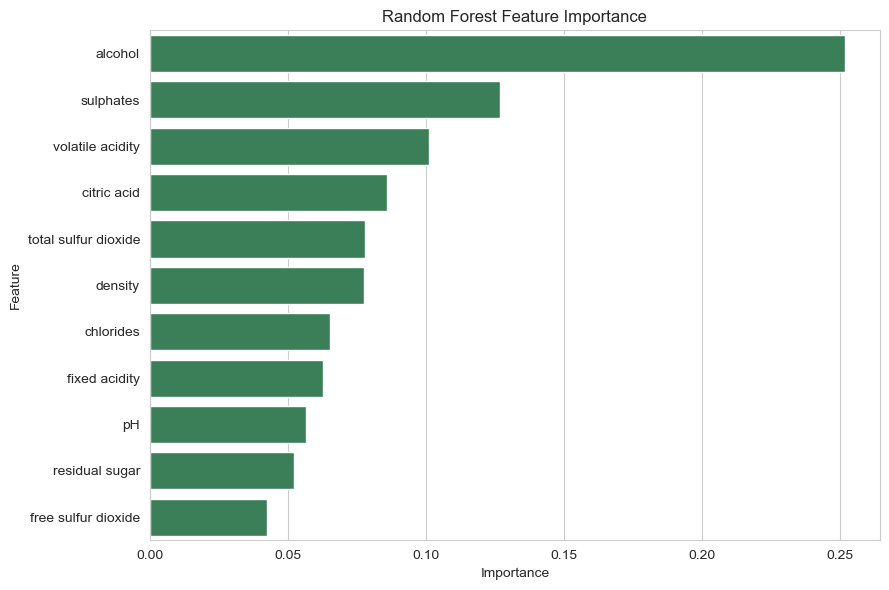

In [38]:
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(9, 6))
sns.barplot(data=importance_df, x='Importance', y='Feature', color='seagreen')
plt.title('Random Forest Feature Importance')
plt.tight_layout()
plt.show()

In [39]:
print(importance_df)

                 Feature  Importance
10               alcohol    0.251742
9              sulphates    0.126955
1       volatile acidity    0.101014
2            citric acid    0.085829
6   total sulfur dioxide    0.077849
7                density    0.077444
4              chlorides    0.065394
0          fixed acidity    0.062543
8                     pH    0.056576
3         residual sugar    0.052175
5    free sulfur dioxide    0.042479


### 11. Comparison Table

In [40]:
results = []
for name, (model, X_te) in models.items():
    y_pred = model.predict(X_te)
    y_proba = model.predict_proba(X_te)[:, 1]
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'AUC': roc_auc_score(y_test, y_proba),
        'Precision (Good)': classification_report(y_test, y_pred, output_dict=True)['1']['precision'],
        'Recall (Good)': classification_report(y_test, y_pred, output_dict=True)['1']['recall'],
        'F1 (Good)': classification_report(y_test, y_pred, output_dict=True)['1']['f1-score'],
    })

results_df = pd.DataFrame(results).sort_values('AUC', ascending=False)
print(results_df)

           Model  Accuracy       AUC  Precision (Good)  Recall (Good)  \
0  Random Forest    0.9400  0.946585          0.916667       0.611111   
2            SVC    0.8325  0.895847          0.431579       0.759259   
1            SGD    0.7200  0.834190          0.295775       0.777778   

   F1 (Good)  
0   0.733333  
2   0.550336  
1   0.428571  


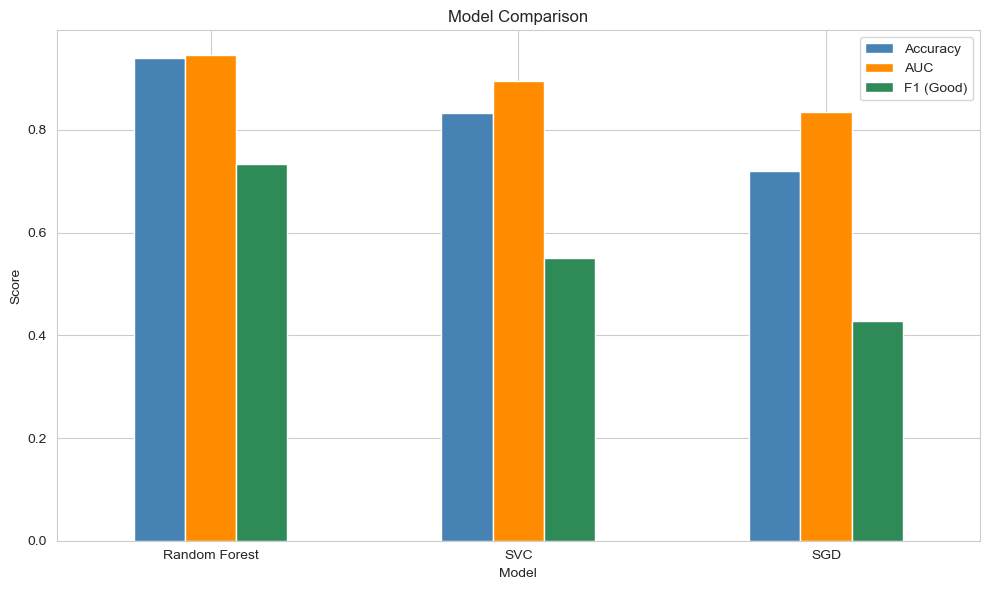

In [41]:
results_df.set_index('Model')[['Accuracy', 'AUC', 'F1 (Good)']].plot(
    kind='bar', figsize=(10, 6), color=['steelblue', 'darkorange', 'seagreen']
)
plt.title('Model Comparison')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Conclusion

Based on AUC and F1-score for the minority "good" class, [fill in after running — likely Random
Forest] performs best. Reasoning to include in your writeup:

- **Random Forest** typically handles non-linear feature interactions well and is fairly robust
  to unscaled/skewed features, and gives interpretable feature importances — a strong choice for
  deployment when interpretability + solid performance both matter.
- **SVC** with an RBF kernel often achieves strong AUC on these small-to-medium tabular datasets
  but is less interpretable and slower to tune/scale to larger data.
- **SGD** (linear model) is fastest to train and easiest to update online, but its linear
  decision boundary usually underperforms if quality depends on nonlinear feature combinations
  (e.g. alcohol × volatile acidity).

For deployment, Random Forest is usually the best trade-off of performance, robustness, and
interpretability unless inference latency or model size is tightly constrained, in which case a
tuned SGD/linear model may be preferable.